Dimensiones del dataset:
(1599, 12)
<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  label                 1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
Valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual

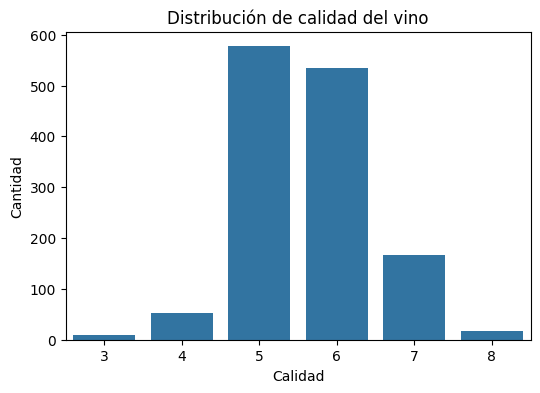

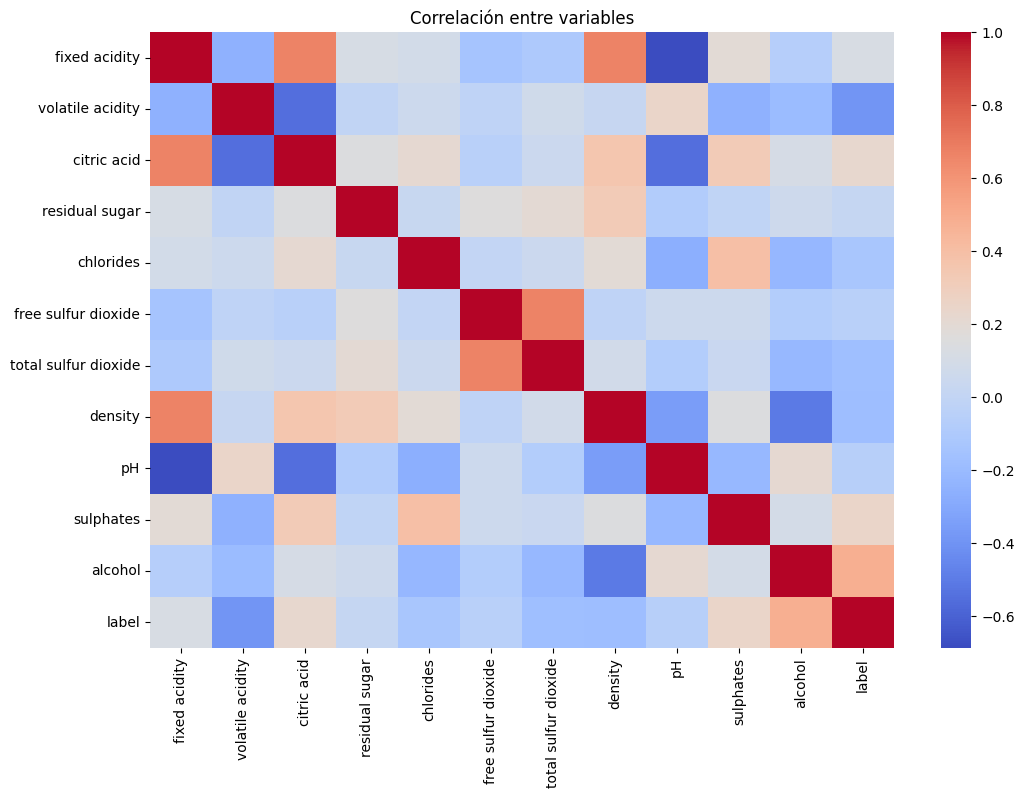

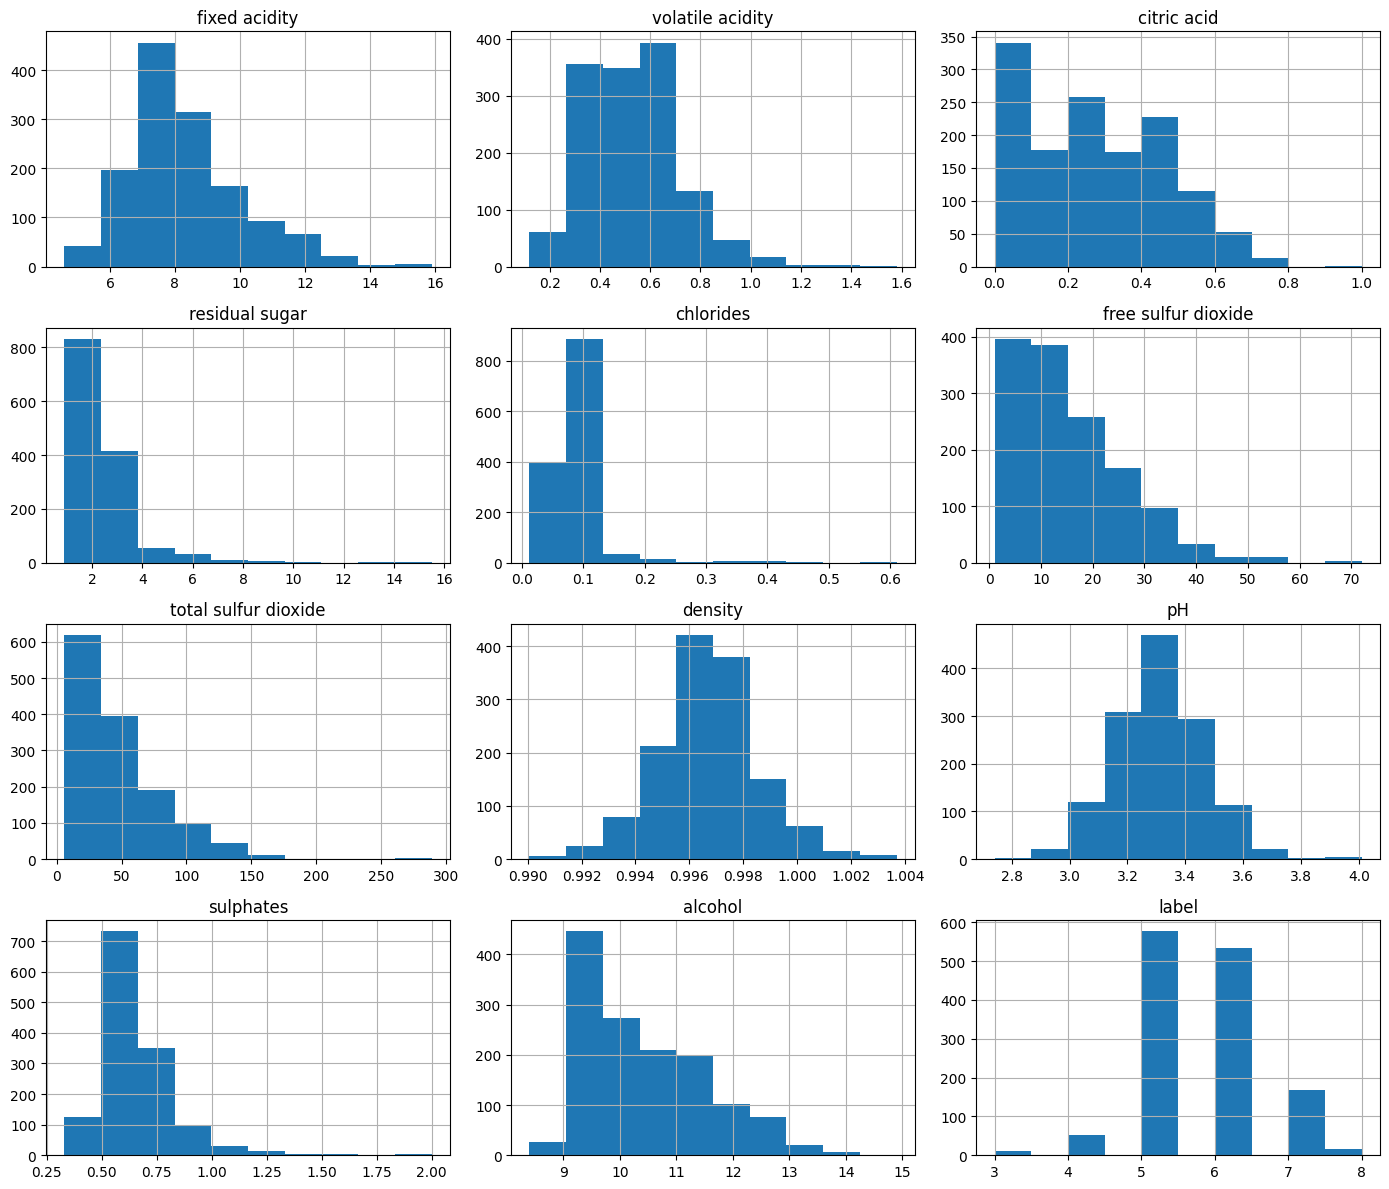

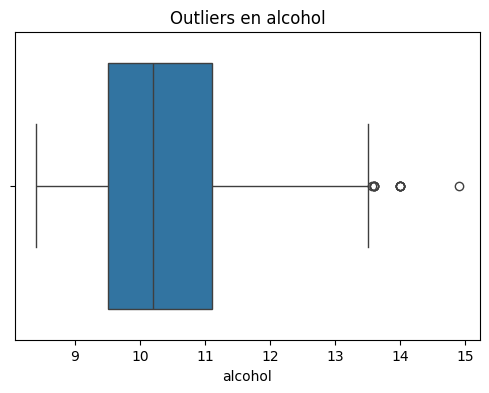



CONCLUSIÓN DEL EDA:

El dataset contiene información química
de vinos tintos clasificados
según su calidad.

No se detectan problemas graves
de valores nulos.

Se eliminaron registros duplicados
para evitar redundancia.

Las variables presentan diferentes escalas,
por lo que será necesario aplicar escalado
antes de entrenar el modelo KNN.

Existen relaciones entre variables químicas
y calidad del vino.

El dataset resulta adecuado
para modelos de clasificación
basados en distancia como KNN.




In [3]:
# =========================================
# EDA COMPLETO - WINE QUALITY DATASET
# =========================================

# =========================
# IMPORTACIÓN DE LIBRERÍAS
# =========================

# pandas -> manejo de datos
# matplotlib y seaborn -> visualización

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# CARGA DEL DATASET
# =========================

# Cargamos el dataset desde GitHub

url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"

# El archivo utiliza ";" como separador

df = pd.read_csv(url, sep=";")

# Renombramos la variable objetivo
# para que coincida con el enunciado

df = df.rename(columns={"quality": "label"})

# Mostramos las primeras filas

df.head()

# =========================
# INFORMACIÓN GENERAL
# =========================

# Mostramos dimensiones del dataset

print("Dimensiones del dataset:")
print(df.shape)

# Información general del dataset

df.info()

"""
El dataset contiene características químicas
de distintos vinos tintos.

La variable objetivo es:
- label

0 -> baja calidad
1 -> calidad media
2 -> alta calidad
"""

# =========================
# ESTADÍSTICAS DESCRIPTIVAS
# =========================

# Resumen estadístico
# de las variables numéricas

df.describe()

"""
Las variables presentan diferentes escalas.

Esto es importante porque KNN
utiliza distancias matemáticas.
"""

# =========================
# VALORES NULOS
# =========================

print("Valores nulos:")
print(df.isnull().sum())

"""
No se observan valores nulos
en el dataset.
"""

# =========================
# DUPLICADOS
# =========================

print("Cantidad de duplicados:")
print(df.duplicated().sum())

"""
Los registros duplicados pueden generar
redundancia durante el entrenamiento.
"""

# =========================
# ELIMINAR DUPLICADOS
# =========================

df = df.drop_duplicates().reset_index(drop=True)

print("Nuevo tamaño del dataset:")
print(df.shape)

"""
Se eliminan registros duplicados
para mejorar la calidad de los datos.
"""

# =========================
# DISTRIBUCIÓN DE CLASES
# =========================

# Visualizamos la cantidad
# de vinos por categoría

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="label"
)

plt.title("Distribución de calidad del vino")
plt.xlabel("Calidad")
plt.ylabel("Cantidad")

plt.show()

"""
Interpretación:

La mayoría de vinos pertenecen
a categorías medias.

El dataset no está completamente balanceado,
aunque sigue siendo válido
para clasificación.
"""

# =========================
# CORRELACIÓN ENTRE VARIABLES
# =========================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlación entre variables")

plt.show()

"""
Interpretación:

Algunas variables químicas
parecen relacionarse
con la calidad del vino.

Por ejemplo:
- alcohol
- sulphates
- acidity
"""

# =========================
# DISTRIBUCIÓN DE VARIABLES
# =========================

# Histogramas de todas las variables

df.hist(figsize=(14,12))

plt.tight_layout()

plt.show()

"""
Las variables presentan distintas distribuciones.

Algunas muestran posibles valores extremos.
"""

# =========================
# ANÁLISIS DE OUTLIERS
# =========================

# Analizamos outliers
# en la variable alcohol

plt.figure(figsize=(6,4))

sns.boxplot(x=df["alcohol"])

plt.title("Outliers en alcohol")

plt.show()

"""
Interpretación:

Se detectan algunos valores extremos
en alcohol.

No se eliminan porque podrían representar
vinos reales de alta graduación.
"""

# =========================
# IMPORTANCIA DEL ESCALADO
# =========================

"""
KNN utiliza distancias entre observaciones.

Por este motivo,
las variables deben escalarse.

Si no se escalan,
variables con valores grandes
dominarán la distancia
y afectarán negativamente
al modelo.
"""

# =========================
# CONCLUSIÓN FINAL DEL EDA
# =========================

print("""

CONCLUSIÓN DEL EDA:

El dataset contiene información química
de vinos tintos clasificados
según su calidad.

No se detectan problemas graves
de valores nulos.

Se eliminaron registros duplicados
para evitar redundancia.

Las variables presentan diferentes escalas,
por lo que será necesario aplicar escalado
antes de entrenar el modelo KNN.

Existen relaciones entre variables químicas
y calidad del vino.

El dataset resulta adecuado
para modelos de clasificación
basados en distancia como KNN.

""")

In [5]:
# Importamos pandas
# Se utiliza para trabajar con datasets
# y estructuras tipo tabla (DataFrame)

import pandas as pd

# Importamos matplotlib.pyplot
# Permite crear gráficos y visualizaciones

import matplotlib.pyplot as plt

# Importamos train_test_split
# Sirve para dividir los datos
# en entrenamiento y prueba

from sklearn.model_selection import train_test_split

# Importamos StandardScaler
# Se utiliza para escalar los datos

# KNN trabaja con distancias,
# por lo que el escalado es muy importante

from sklearn.preprocessing import StandardScaler

# Importamos KNeighborsClassifier
# Este es el modelo KNN
# (K-Nearest Neighbors)

from sklearn.neighbors import KNeighborsClassifier

# Importamos métricas de evaluación

# accuracy_score:
# porcentaje de predicciones correctas

# confusion_matrix:
# muestra aciertos y errores
# por categoría

# classification_report:
# resumen completo del rendimiento
# del modelo

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [7]:
# =========================
# CARGA DEL DATASET
# =========================

# Definimos la URL
# donde se encuentra el dataset

url = "https://raw.githubusercontent.com/rosinni/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"

# Cargamos el archivo CSV utilizando pandas

# sep=";" indica que las columnas
# están separadas por punto y coma

df = pd.read_csv(url, sep=";")

# Mostramos las primeras filas
# del dataset para comprobar
# que la carga se realizó correctamente

df.head()



,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
# =========================
# CREACIÓN DE LA VARIABLE OBJETIVO
# =========================

# Creamos una función para convertir
# la puntuación original del vino
# en categorías de calidad

def quality_to_label(q):

    # Si la calidad es 4 o menor
    # se considera vino de baja calidad

    if q <= 4:
        return 0  # baja

    # Si la calidad está entre 5 y 6
    # se considera calidad media

    elif q <= 6:
        return 1  # media

    # Si la calidad es superior a 6
    # se considera vino de alta calidad

    else:
        return 2  # alta

# Aplicamos la función sobre la columna quality

# apply() recorre cada valor
# de la columna quality

# El resultado se guarda
# en una nueva columna llamada label

df['label'] = df['quality'].apply(quality_to_label)

# Objetivo:
# transformar una variable numérica continua
# en categorías para poder utilizar
# un modelo de clasificación KNN.

# Resultado:
# 0 -> baja calidad
# 1 -> calidad media
# 2 -> alta calidad

In [9]:
# =========================
# SEPARACIÓN DE VARIABLES
# =========================

# X contiene las variables predictoras
# (las características químicas del vino)

# Eliminamos:
# - label -> variable objetivo creada
# - quality -> puntuación original

# axis=1 indica que eliminamos columnas

X = df.drop(
    ["label", "quality"],
    axis=1
)

# y contiene la variable objetivo

# Esta variable representa
# la categoría de calidad del vino:
# 0 -> baja
# 1 -> media
# 2 -> alta

y = df["label"]

# Objetivo:
# separar correctamente
# las variables independientes (X)
# de la variable dependiente (y)
# antes de entrenar el modelo KNN.

In [10]:
# 3. Dividir los datos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# =========================
# ESCALADO DE LOS DATOS
# =========================

# Creamos un objeto StandardScaler

# Este método estandariza los datos:
# - media = 0
# - desviación estándar = 1

# El escalado es muy importante en KNN
# porque el modelo utiliza distancias
# entre observaciones

scaler = StandardScaler()

# Ajustamos el scaler utilizando
# únicamente los datos de entrenamiento

# fit_transform():
# - aprende los parámetros de escalado
# - transforma los datos

X_train_scaled = scaler.fit_transform(X_train)

# Transformamos los datos de prueba
# utilizando los mismos parámetros
# aprendidos en train

# IMPORTANTE:
# aquí NO usamos fit_transform()
# para evitar data leakage

X_test_scaled = scaler.transform(X_test)

# Objetivo:
# asegurar que todas las variables
# tengan la misma escala
# y ninguna domine las distancias
# utilizadas por KNN.

In [12]:
# =========================
# ENTRENAMIENTO DEL MODELO KNN
# =========================

# Creamos el modelo KNN

# n_neighbors=5 indica que el modelo
# utilizará los 5 vecinos más cercanos
# para clasificar cada observación

knn = KNeighborsClassifier(n_neighbors=5)

# Entrenamos el modelo utilizando:
# - X_train_scaled -> variables escaladas
# - y_train -> categorías reales

knn.fit(X_train_scaled, y_train)

# Generamos predicciones
# sobre los datos de prueba

y_pred = knn.predict(X_test_scaled)

# =========================
# EVALUACIÓN DEL MODELO
# =========================

# Calculamos el accuracy

# accuracy_score mide
# el porcentaje de predicciones correctas

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

# Mostramos la matriz de confusión

# confusion_matrix permite visualizar:
# - aciertos
# - errores
# - clases confundidas

print(
    "\nMatriz de confusión:\n",
    confusion_matrix(y_test, y_pred)
)

# Mostramos el classification report

# Este reporte incluye:
# - precision
# - recall
# - f1-score
# - support

print(
    "\nReporte de clasificación:\n",
    classification_report(y_test, y_pred)
)

"""
Interpretación:

El modelo KNN clasifica cada vino
comparándolo con los vinos
más similares del dataset.

El valor k=5 significa que
la predicción se basa
en los 5 vecinos más cercanos.

Las métricas permiten analizar:
- precisión global
- errores de clasificación
- rendimiento por categoría.
"""

Accuracy: 0.84375

Matriz de confusión:
 [[  0  11   0]
 [  1 250  11]
 [  0  27  20]]

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.87      0.95      0.91       262
           2       0.65      0.43      0.51        47

    accuracy                           0.84       320
   macro avg       0.50      0.46      0.47       320
weighted avg       0.81      0.84      0.82       320



'\nInterpretación:\n\nEl modelo KNN clasifica cada vino\ncomparándolo con los vinos\nmás similares del dataset.\n\nEl valor k=5 significa que\nla predicción se basa\nen los 5 vecinos más cercanos.\n\nLas métricas permiten analizar:\n- precisión global\n- errores de clasificación\n- rendimiento por categoría.\n'

In [13]:
# =========================
# BÚSQUEDA DEL MEJOR VALOR DE k
# =========================

# Creamos un rango de valores
# para probar distintos vecinos

# range(1, 21):
# probará valores de k
# desde 1 hasta 20

k_range = range(1, 21)

# Lista vacía donde guardaremos
# los accuracy obtenidos
# para cada valor de k

accuracies = []

# Recorremos todos los valores de k

for k in k_range:

    # Creamos un modelo KNN
    # utilizando el valor actual de k

    model = KNeighborsClassifier(
        n_neighbors=k
    )

    # Entrenamos el modelo

    model.fit(
        X_train_scaled,
        y_train
    )

    # Generamos predicciones
    # sobre los datos de prueba

    y_k_pred = model.predict(
        X_test_scaled
    )

    # Calculamos accuracy
    # y lo guardamos en la lista

    accuracies.append(
        accuracy_score(
            y_test,
            y_k_pred
        )
    )

"""
Objetivo:

Encontrar el valor de k
que produce mejor rendimiento.

Valores pequeños de k:
- pueden generar overfitting

Valores grandes de k:
- pueden simplificar demasiado el modelo

Por eso es importante probar
distintos valores y comparar resultados.
"""

'\nObjetivo:\n\nEncontrar el valor de k\nque produce mejor rendimiento.\n\nValores pequeños de k:\n- pueden generar overfitting\n\nValores grandes de k:\n- pueden simplificar demasiado el modelo\n\nPor eso es importante probar\ndistintos valores y comparar resultados.\n'

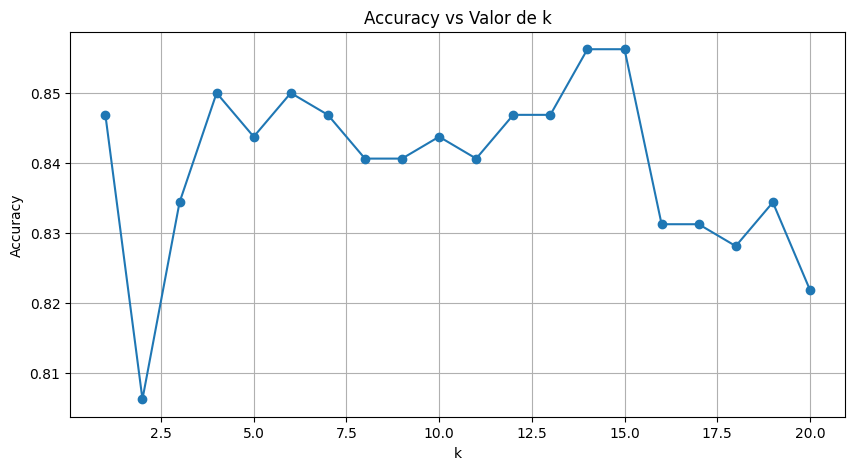

'\nInterpretación:\n\nLa gráfica permite visualizar\ncómo cambia el rendimiento\ndel modelo según el valor de k.\n\nEl mejor valor de k será aquel\nque obtenga el mayor accuracy.\n\nEsta técnica ayuda a optimizar\nel modelo KNN y evitar:\n- overfitting\n- underfitting\n'

In [14]:
# =========================
# GRÁFICA ACCURACY VS k
# =========================

# Creamos una figura
# y definimos su tamaño

plt.figure(figsize=(10, 5))

# Dibujamos la gráfica

# k_range:
# valores de k probados

# accuracies:
# accuracy obtenido para cada k

# marker='o':
# añade puntos visibles en la línea

plt.plot(
    k_range,
    accuracies,
    marker='o'
)

# Añadimos título al gráfico

plt.title("Accuracy vs Valor de k")

# Etiqueta del eje X

plt.xlabel("k")

# Etiqueta del eje Y

plt.ylabel("Accuracy")

# Mostramos una cuadrícula
# para facilitar la lectura

plt.grid(True)

# Mostramos la gráfica

plt.show()

"""
Interpretación:

La gráfica permite visualizar
cómo cambia el rendimiento
del modelo según el valor de k.

El mejor valor de k será aquel
que obtenga el mayor accuracy.

Esta técnica ayuda a optimizar
el modelo KNN y evitar:
- overfitting
- underfitting
"""

## Interpretación de la gráfica

La gráfica muestra cómo varía el accuracy del modelo KNN
según el valor de k utilizado.

Se observa que los mejores resultados se obtienen
aproximadamente entre k = 13 y k = 15,
donde el accuracy alcanza su valor máximo.

Cuando k es demasiado pequeño,
el modelo puede sufrir overfitting,
ya que se vuelve muy sensible
a observaciones individuales.

Por otro lado,
cuando k aumenta demasiado,
el accuracy comienza a disminuir,
lo que indica una pérdida de precisión
debido a un exceso de generalización.

En este caso,
un valor intermedio de k
ofrece el mejor equilibrio
entre precisión y capacidad de generalización.

Por ello,
los valores cercanos a k = 14
parecen ser la mejor opción
para este problema de clasificación de vinos.

In [15]:
# =========================
# SELECCIÓN DEL MEJOR k
# =========================

# Buscamos el valor máximo
# dentro de la lista accuracies

# accuracies.index(max(accuracies)):
# devuelve la posición
# donde se encuentra
# el mayor accuracy

# Después utilizamos esa posición
# para obtener el valor de k correspondiente

best_k = k_range[
    accuracies.index(
        max(accuracies)
    )
]

# Mostramos el mejor valor de k

print(
    f"Mejor valor de k: {best_k}"
)

"""
Interpretación:

El mejor valor de k es aquel
que obtiene el mayor accuracy
durante las pruebas realizadas.

Este valor representa
el número óptimo de vecinos
que el modelo debe utilizar
para clasificar correctamente
los vinos.

Seleccionar correctamente k
es fundamental para equilibrar:
- precisión
- generalización
- estabilidad del modelo
"""

Mejor valor de k: 14


'\nInterpretación:\n\nEl mejor valor de k es aquel\nque obtiene el mayor accuracy\ndurante las pruebas realizadas.\n\nEste valor representa\nel número óptimo de vecinos\nque el modelo debe utilizar\npara clasificar correctamente\nlos vinos.\n\nSeleccionar correctamente k\nes fundamental para equilibrar:\n- precisión\n- generalización\n- estabilidad del modelo\n'

In [17]:
# =========================
# ENTRENAMIENTO DEL MODELO FINAL
# =========================

# Creamos el modelo KNN final

# Utilizamos el mejor valor de k
# encontrado durante la optimización

final_knn = KNeighborsClassifier(
    n_neighbors=best_k
)

# Entrenamos el modelo final
# utilizando los datos escalados
# de entrenamiento

final_knn.fit(
    X_train_scaled,
    y_train
)



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",14
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [19]:
# =========================
# FUNCIÓN DE PREDICCIÓN
# =========================

# Creamos una función
# que recibe características químicas
# de un vino y devuelve
# una predicción de calidad

def predict_wine_quality(features):

    # Escalamos los datos de entrada
    # utilizando el mismo scaler
    # entrenado anteriormente

    features_scaled = scaler.transform([features])

    # Realizamos la predicción

    pred = final_knn.predict(features_scaled)[0]

    # Devolvemos un mensaje
    # según la categoría predicha

    if pred == 0:
        return "Este vino probablemente sea de baja calidad"

    elif pred == 1:
        return "Este vino probablemente sea de calidad media"

    else:
        return "Este vino probablemente sea de alta calidad"



In [20]:
# =========================
# PRUEBA DE LA FUNCIÓN
# =========================

# Introducimos manualmente
# las características químicas
# de un vino

resultado = predict_wine_quality([
    7.4,     # fixed acidity
    0.7,     # volatile acidity
    0.0,     # citric acid
    1.9,     # residual sugar
    0.076,   # chlorides
    11.0,    # free sulfur dioxide
    34.0,    # total sulfur dioxide
    0.9978,  # density
    3.51,    # pH
    0.56,    # sulphates
    9.4      # alcohol
])

# Mostramos la predicción obtenida

print(
    "\nPredicción de ejemplo:",
    resultado
)

"""
Interpretación:

La función utiliza el modelo KNN
entrenado anteriormente
para estimar la calidad del vino.

Las características químicas introducidas
son procesadas y comparadas
con vinos similares del dataset.

El modelo devuelve una categoría:
- baja calidad
- calidad media
- alta calidad
"""


Predicción de ejemplo: Este vino probablemente sea de calidad media


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


'\nInterpretación:\n\nLa función utiliza el modelo KNN\nentrenado anteriormente\npara estimar la calidad del vino.\n\nLas características químicas introducidas\nson procesadas y comparadas\ncon vinos similares del dataset.\n\nEl modelo devuelve una categoría:\n- baja calidad\n- calidad media\n- alta calidad\n'

In [21]:
# =========================
# GUARDAR MODELO
# =========================

from pickle import dump
import os

# Creamos carpeta models
# si no existe

os.makedirs("../models", exist_ok=True)

# Guardamos el modelo entrenado

dump(
    final_knn,
    open(
        "../models/knn_wine_classifier.sav",
        "wb"
    )
)

print("Modelo guardado correctamente.")

Modelo guardado correctamente.


## Conclusión Final

En este proyecto se desarrolló un modelo KNN
para clasificar vinos tintos según su calidad
a partir de sus características químicas.

Se realizó un análisis exploratorio de datos,
preprocesamiento y escalado de variables,
paso fundamental en modelos basados en distancia.

Posteriormente se entrenó un modelo inicial
y se optimizó el valor de k
comparando distintos resultados de accuracy.

El modelo final consiguió clasificar
correctamente gran parte de los vinos,
demostrando que las características químicas
pueden utilizarse para estimar la calidad
de un vino mediante Machine Learning.

Además, se implementó una función predictora
capaz de clasificar nuevos vinos
a partir de sus propiedades químicas.